# England vs France 2026 World Cup third-place match: competitive or fun?

## Objective

The question is whether England 6–4 France (18 July 2026 local time in Miami; 19 July in Indonesia) was merely a fun exhibition or a genuinely competitive World Cup match. The analysis separates two ideas that are easy to conflate:

- **Official status:** it was an official FIFA World Cup third-place playoff, not a friendly.
- **Competitive stakes:** it awarded the bronze-medal position but did not decide the world champion, so it is a lower-stakes match than the title-path knockout rounds.

I operationalize the user's “fun-match” idea with a direct charity-exhibition benchmark: Soccer Aid for UNICEF, an England vs World XI celebrity/former-player match series from 2006–2026. I compare it with men's World Cup third-place playoffs, title-path knockout matches, and group/second-group matches. The comparison is about goal rate, defensive looseness, and score closeness; it cannot directly observe player motivation.

### What counts as evidence

1. Historical goal distributions from the reused Fjelstul World Cup database (1930–2022).
2. Regulation-time scores from 15 Soccer Aid charity exhibitions (2006–2026).
3. Goal timing and final score for the 2026 match.
4. Current-match possession, shots, xG, chances, fouls, cards, and passing statistics from the FOX Sports box score.
5. Non-parametric and randomization tests, with the small comparison samples called out explicitly.

In [4]:
# Setup: imports, reproducibility, paths, and plotting style
from __future__ import annotations

import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy import stats

SEED = 42
random.seed(SEED)
rng = np.random.default_rng(SEED)

PROJECT_ROOT_CANDIDATES = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent, Path(r"C:\Users\miqba\projects\Match Analyzer")]
PROJECT_ROOT = next((candidate for candidate in PROJECT_ROOT_CANDIDATES if (candidate / "data" / "current_match_goals.csv").exists()), Path.cwd())
ARGENTINA_ROOT = Path(os.environ.get("ARGENTINA_COMEBACK_ROOT", r"C:\Users\miqba\projects\Argentina Comeback Analysis"))
FJELSTUL_DIR = ARGENTINA_ROOT / "data" / "raw" / "fjelstul"
CURRENT_GOALS_PATH = PROJECT_ROOT / "data" / "current_match_goals.csv"
SOCCER_AID_PATH = PROJECT_ROOT / "data" / "soccer_aid_results.csv"
ASSETS_DIR = PROJECT_ROOT / "output" / "assets"
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160, "axes.titleweight": "bold"})
print("Notebook root:", PROJECT_ROOT)
print("Reused historical data:", FJELSTUL_DIR)
print("Current match goal snapshot:", CURRENT_GOALS_PATH)
print("Fun/charity benchmark:", SOCCER_AID_PATH)

Notebook root: c:\Users\miqba\projects\Match Analyzer
Reused historical data: C:\Users\miqba\projects\Argentina Comeback Analysis\data\raw\fjelstul
Current match goal snapshot: c:\Users\miqba\projects\Match Analyzer\data\current_match_goals.csv
Fun/charity benchmark: c:\Users\miqba\projects\Match Analyzer\data\soccer_aid_results.csv


## Sources and match snapshot

The current-match facts are a point-in-time snapshot, not a live feed. Historical data is loaded from the sibling project at execution time so the notebook can be rerun against that exact local copy.

- Historical World Cup data: [Fjelstul World Cup Database, pinned commit](https://github.com/jfjelstul/worldcup/tree/35a8667f518b07469182ae16d35574dd0e7a00fb/data-csv)
- Match report and goal chronology: [11v11 match report](https://www.11v11.com/matches/france-v-england-18-july-2026-393896/)
- Match narrative and record context: [Associated Press report](https://apnews.com/article/world-cup-england-france-third-place-score-52f94eda6ff6d268d38aaefbc446c525)
- Current match team statistics: [FOX Sports box score](https://www.foxsports.com/soccer/fifa-world-cup-men-france-vs-england-jul-18-2026-game-boxscore-607933?tab=boxscore)
- Competition framing and third-place history: [England Football stat pack](https://www.englandfootball.com/articles/2026/Jul/16/app-england-france-world-cup-stat-pack-20261607)
- Charity-exhibition benchmark results: [Soccer Aid results](https://en.wikipedia.org/wiki/Soccer_Aid), [official 2024 report](https://www.socceraid.org.uk/2024-match-report/), [official 2025 report](https://www.socceraid.org.uk/2025-match-report/), and [UNICEF's 2026 report](https://www.unicef.org.uk/press-releases/soccer-aid-for-unicef-2026-raises-a-record-16-million-for-children-around-the-world-20th-anniversary-match-a-sell-out-success-at-london-stadium/)

In [5]:
# Current-match metadata from the cited sources
CURRENT_MATCH = {
    "date": "2026-07-18",
    "venue": "Hard Rock Stadium, Miami Gardens",
    "competition": "FIFA World Cup third-place playoff",
    "home_team": "France",
    "away_team": "England",
    "france_goals": 4,
    "england_goals": 6,
}

CURRENT_MATCH_STATS = pd.DataFrame([
    ("Possession (%)", 45, 55),
    ("Total shots", 18, 18),
    ("Shots on goal", 9, 10),
    ("Expected goals (xG)", 2.67, 3.00),
    ("Chances created", 15, 13),
    ("Passing accuracy (%)", 92, 93),
    ("Corners", 3, 4),
    ("Fouls", 13, 7),
    ("Yellow cards", 0, 0),
    ("Red cards", 0, 0),
], columns=["metric", "France", "England"]).set_index("metric")

display(pd.Series(CURRENT_MATCH, name="value").to_frame())
display(CURRENT_MATCH_STATS)

,value
date,2026-07-18
venue,"Hard Rock Stadium, Miami Gardens"
competition,FIFA World Cup third-place playoff
home_team,France
away_team,England
france_goals,4
england_goals,6


,France,England
metric,,
Possession (%),45.00,55.0
Total shots,18.00,18.0
Shots on goal,9.00,10.0
Expected goals (xG),2.67,3.0
Chances created,15.00,13.0
Passing accuracy (%),92.00,93.0
Corners,3.00,4.0
Fouls,13.00,7.0
Yellow cards,0.00,0.0


In [6]:
# Load the reusable World Cup history and the local 2026 goal snapshot
matches_raw = pd.read_csv(FJELSTUL_DIR / "matches.csv", encoding="utf-8-sig")
goals_raw = pd.read_csv(FJELSTUL_DIR / "goals.csv", encoding="utf-8-sig")
bookings_raw = pd.read_csv(FJELSTUL_DIR / "bookings.csv", encoding="utf-8-sig")
current_goals = pd.read_csv(CURRENT_GOALS_PATH)
soccer_aid = pd.read_csv(SOCCER_AID_PATH)

men = matches_raw[matches_raw["tournament_name"].str.contains("Men's World Cup", regex=False, na=False)].copy()
men["edition_year"] = pd.to_datetime(men["match_date"]).dt.year
men[["home_team_score", "away_team_score"]] = men[["home_team_score", "away_team_score"]].apply(pd.to_numeric)

print(f"Loaded {len(matches_raw):,} total World Cup match rows; {len(men):,} men's rows across {men.tournament_name.nunique()} editions.")
print(f"Loaded {len(soccer_aid)} Soccer Aid charity exhibitions.")
display(men[["tournament_name", "stage_name", "match_name", "home_team_score", "away_team_score"]].head(3))

Loaded 1,248 total World Cup match rows; 964 men's rows across 22 editions.
Loaded 15 Soccer Aid charity exhibitions.


,tournament_name,stage_name,match_name,home_team_score,away_team_score
0,1930 FIFA Men's World Cup,group stage,France vs Mexico,4,1
1,1930 FIFA Men's World Cup,group stage,United States vs Belgium,3,0
2,1930 FIFA Men's World Cup,group stage,Yugoslavia vs Brazil,2,1


## Data-quality checks

The intended historical grain is one row per men's World Cup match. Scores are final match scores in the source data; the notebook does not combine women's tournaments with the men's comparison.

In [7]:
quality_checks = pd.DataFrame([
    ("historical rows", len(men), "expected > 0"),
    ("unique match IDs", men["match_id"].nunique(), "equal to rows"),
    ("missing home scores", men["home_team_score"].isna().sum(), "0"),
    ("missing away scores", men["away_team_score"].isna().sum(), "0"),
    ("third-place rows", (men["stage_name"] == "third-place match").sum(), "20 through 2022"),
    ("current goal rows", len(current_goals), "10"),
    ("Soccer Aid rows", len(soccer_aid), "15"),
], columns=["check", "observed", "expected"])
display(quality_checks)
assert men["match_id"].is_unique
assert men[["home_team_score", "away_team_score"]].notna().all().all()
assert len(current_goals) == CURRENT_MATCH["france_goals"] + CURRENT_MATCH["england_goals"]
assert len(soccer_aid) == soccer_aid["year"].nunique() == 15
assert soccer_aid[["team_a_goals", "team_b_goals"]].notna().all().all()

,check,observed,expected
0,historical rows,964,expected > 0
1,unique match IDs,964,equal to rows
2,missing home scores,0,0
3,missing away scores,0,0
4,third-place rows,20,20 through 2022
5,current goal rows,10,10
6,Soccer Aid rows,15,15


In [8]:
# Create comparable historical contexts and match-level measures
TITLE_PATH_STAGES = {"round of 16", "quarter-finals", "semi-finals", "final"}
men["context"] = np.select(
    [
        men["stage_name"].eq("third-place match"),
        men["stage_name"].isin(TITLE_PATH_STAGES),
    ],
    ["Third-place playoff", "Title-path knockout"],
    default="Group / second-group",
)
men["total_goals"] = men["home_team_score"] + men["away_team_score"]
men["final_margin"] = (men["home_team_score"] - men["away_team_score"]).abs()
men["high_scoring_5_plus"] = men["total_goals"] >= 5
men["one_goal_game"] = men["final_margin"] == 1

soccer_aid["edition_year"] = soccer_aid["year"].astype(int)
soccer_aid["match_id"] = "SA-" + soccer_aid["year"].astype(str)
soccer_aid["total_goals"] = soccer_aid["team_a_goals"] + soccer_aid["team_b_goals"]
soccer_aid["final_margin"] = (soccer_aid["team_a_goals"] - soccer_aid["team_b_goals"]).abs()
soccer_aid["high_scoring_5_plus"] = soccer_aid["total_goals"] >= 5
soccer_aid["one_goal_game"] = soccer_aid["final_margin"] == 1
soccer_aid["context"] = "Fun / charity exhibition"

CONTEXT_ORDER = ["Group / second-group", "Title-path knockout", "Third-place playoff", "Fun / charity exhibition"]
men["context"] = pd.Categorical(men["context"], categories=CONTEXT_ORDER, ordered=True)
comparison_matches = pd.concat([
    men[["match_id", "edition_year", "context", "total_goals", "final_margin", "high_scoring_5_plus", "one_goal_game"]],
    soccer_aid[["match_id", "edition_year", "context", "total_goals", "final_margin", "high_scoring_5_plus", "one_goal_game"]],
], ignore_index=True)
comparison_matches["context"] = pd.Categorical(comparison_matches["context"], categories=CONTEXT_ORDER, ordered=True)

display(comparison_matches.groupby("context", observed=True).size().rename("matches").to_frame())

,matches
context,
Group / second-group,718
Title-path knockout,226
Third-place playoff,20
Fun / charity exhibition,15


In [9]:
# Descriptive comparison: goals, closeness, and high-scoring frequency
summary = (
    comparison_matches.groupby("context", observed=True)
    .agg(
        matches=("match_id", "size"),
        avg_total_goals=("total_goals", "mean"),
        median_total_goals=("total_goals", "median"),
        sd_total_goals=("total_goals", "std"),
        avg_final_margin=("final_margin", "mean"),
        one_goal_game_pct=("one_goal_game", "mean"),
        five_plus_goal_pct=("high_scoring_5_plus", "mean"),
    )
)
summary["one_goal_game_pct"] *= 100
summary["five_plus_goal_pct"] *= 100
display(summary.round({"avg_total_goals": 2, "median_total_goals": 1, "sd_total_goals": 2, "avg_final_margin": 2, "one_goal_game_pct": 1, "five_plus_goal_pct": 1}))

current_summary = pd.DataFrame({
    "current England–France": [10, 1, 2, 0, 100],
}, index=["total goals", "margin above third-place historical maximum", "final margin", "one-goal final", "five-plus-goal match"])
display(current_summary)

,matches,avg_total_goals,median_total_goals,sd_total_goals,avg_final_margin,one_goal_game_pct,five_plus_goal_pct
context,,,,,,,
Group / second-group,718,2.69,2.0,1.86,1.49,37.2,14.5
Title-path knockout,226,3.15,3.0,2.09,1.48,45.1,23.9
Third-place playoff,20,3.80,3.5,1.96,1.60,60.0,35.0
Fun / charity exhibition,15,5.13,5.0,2.07,1.13,33.3,53.3


,current England–France
total goals,10
margin above third-place historical maximum,1
final margin,2
one-goal final,0
five-plus-goal match,100


## Visualization plan

- A distribution plot compares total-goal spread across official World Cup contexts and the Soccer Aid charity-exhibition benchmark, marking the current match at 10.
- A historical third-place bar chart shows whether 2026 is an ordinary high-scoring playoff or an outlier.
- A score-state timeline separates the first-half England rout from France's second-half comeback.
- A current-match box-score chart shows that the 10 goals were accompanied by 18–18 shots, 9–10 shots on goal, and 2.67–3.00 xG—not just random finishing noise in a low-event game.

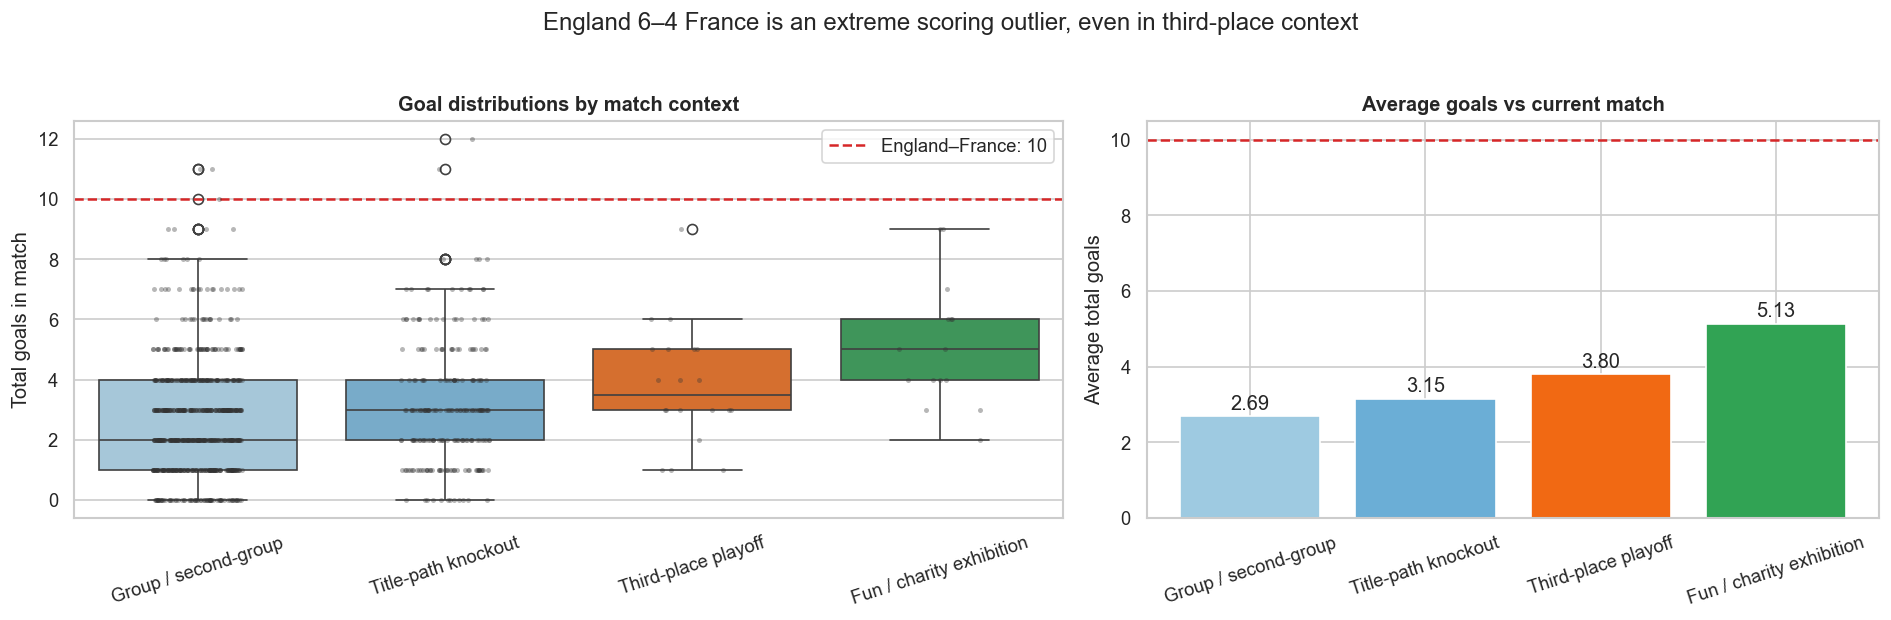

In [10]:
# Chart 1: goal distribution by match context
fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [1.35, 1]})
palette = {"Group / second-group": "#9ecae1", "Title-path knockout": "#6baed6", "Third-place playoff": "#f16913", "Fun / charity exhibition": "#31a354"}

sns.boxplot(data=comparison_matches, x="context", y="total_goals", order=CONTEXT_ORDER, palette=palette, ax=axes[0], hue="context", legend=False)
sns.stripplot(data=comparison_matches, x="context", y="total_goals", order=CONTEXT_ORDER, color="#333333", alpha=0.35, size=3, jitter=0.18, ax=axes[0])
axes[0].axhline(10, color="#d62728", linestyle="--", linewidth=1.5, label="England–France: 10")
axes[0].set_title("Goal distributions by match context")
axes[0].set_xlabel("")
axes[0].set_ylabel("Total goals in match")
axes[0].tick_params(axis="x", rotation=18)
axes[0].legend(frameon=True)

plot_summary = summary.reindex(CONTEXT_ORDER)
axes[1].bar(plot_summary.index, plot_summary["avg_total_goals"], color=[palette[c] for c in CONTEXT_ORDER])
axes[1].axhline(10, color="#d62728", linestyle="--", linewidth=1.5)
axes[1].set_title("Average goals vs current match")
axes[1].set_ylabel("Average total goals")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=18)
for i, value in enumerate(plot_summary["avg_total_goals"]):
    axes[1].text(i, value + 0.08, f"{value:.2f}", ha="center", va="bottom")

fig.suptitle("England 6–4 France is an extreme scoring outlier, even in third-place context", y=1.03)
fig.tight_layout()
fig.savefig(ASSETS_DIR / "goal_distribution_by_context.png", bbox_inches="tight")
plt.show()

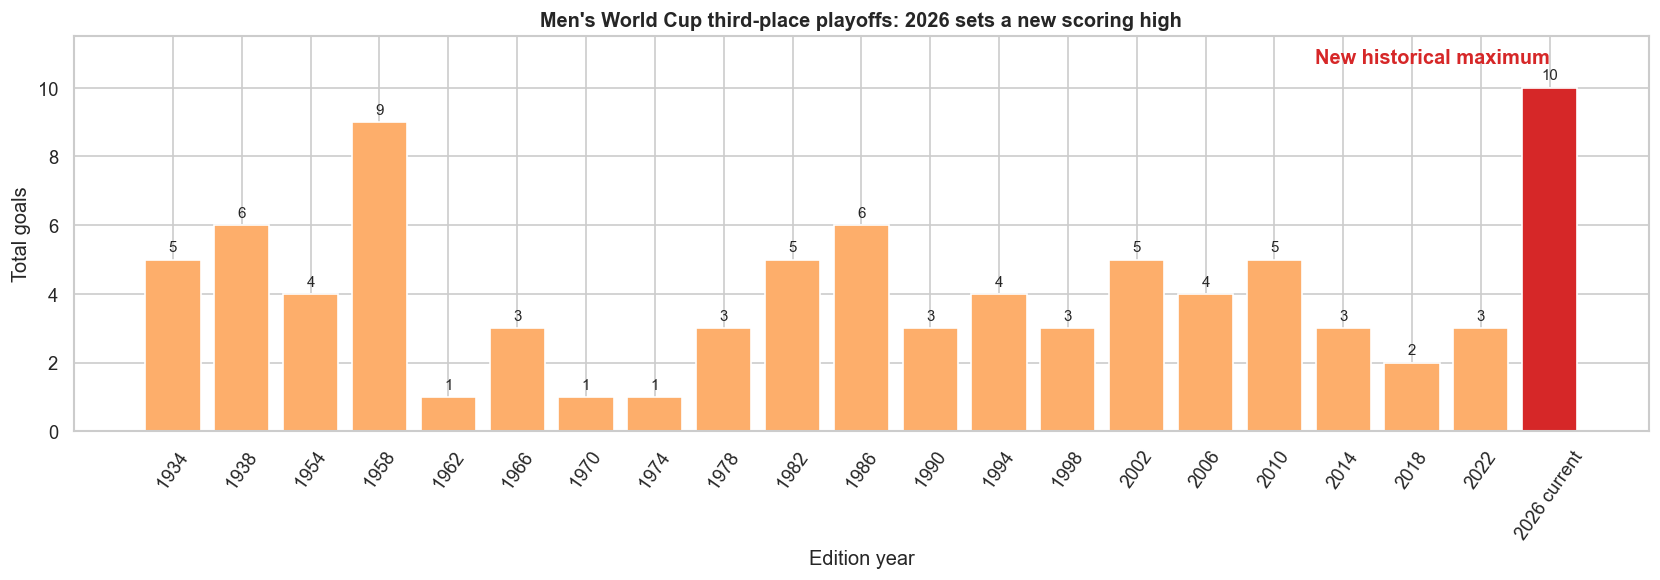

,edition_year,match_name,total_goals
134,1958,France vs West Germany,9
51,1938,Brazil vs Sweden,6
410,1986,Belgium vs France,6
33,1934,Germany vs Austria,5
918,2010,Uruguay vs Germany,5


In [11]:
# Chart 2: all historical men's third-place playoffs, then append the current match
third_history = men[men["context"] == "Third-place playoff"].copy().sort_values("edition_year")
third_plot = third_history[["edition_year", "total_goals"]].copy()
third_plot = pd.concat([third_plot, pd.DataFrame({"edition_year": [2026], "total_goals": [10]})], ignore_index=True)
third_plot["label"] = np.where(third_plot["edition_year"] == 2026, "2026 current", third_plot["edition_year"].astype(str))

fig, ax = plt.subplots(figsize=(14, 5))
colors = ["#d62728" if year == 2026 else "#fdae6b" for year in third_plot["edition_year"]]
bars = ax.bar(third_plot["label"], third_plot["total_goals"], color=colors)
ax.set_title("Men's World Cup third-place playoffs: 2026 sets a new scoring high")
ax.set_ylabel("Total goals")
ax.set_xlabel("Edition year")
ax.set_ylim(0, 11.5)
ax.tick_params(axis="x", rotation=55)
for bar, value in zip(bars, third_plot["total_goals"]):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.15, str(int(value)), ha="center", va="bottom", fontsize=9)
ax.text(len(third_plot) - 1, 10.7, "New historical maximum", ha="right", color="#d62728", fontweight="bold")
fig.tight_layout()
fig.savefig(ASSETS_DIR / "third_place_history.png", bbox_inches="tight")
plt.show()

display(third_history[["edition_year", "match_name", "total_goals"]].sort_values("total_goals", ascending=False).head(5))

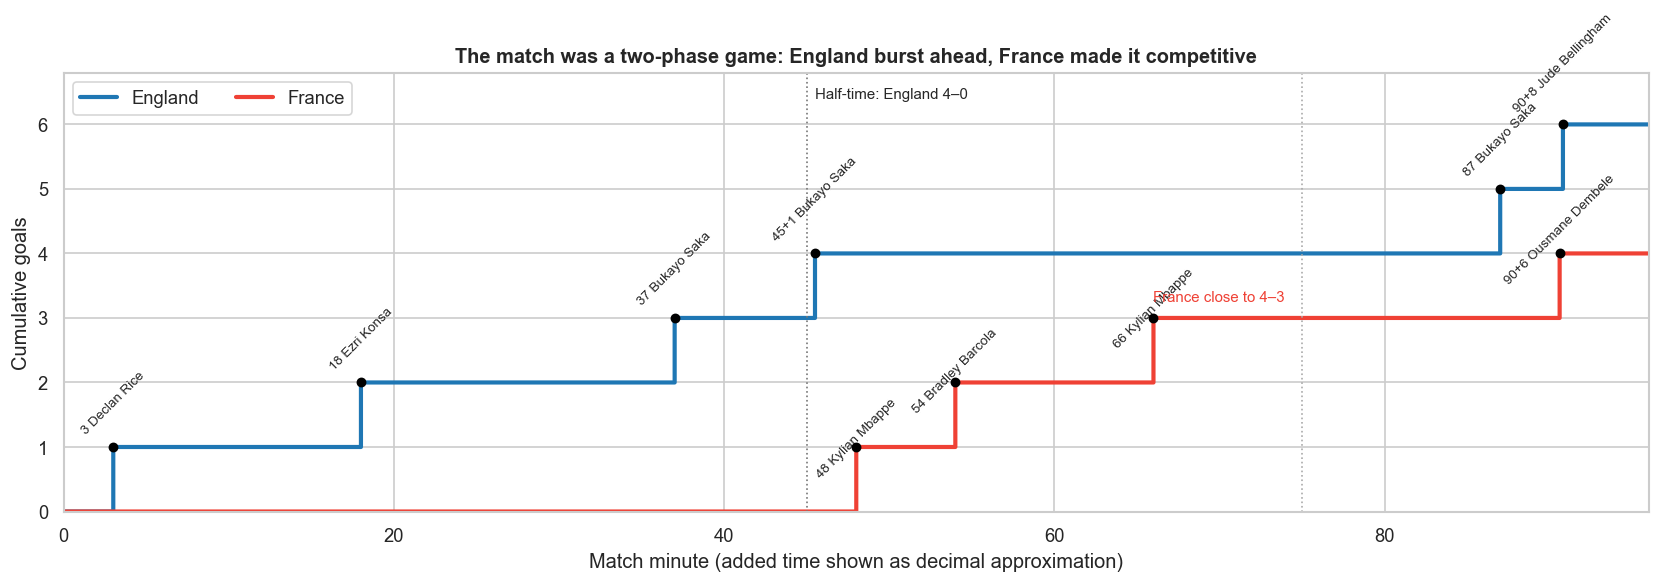

,minute,team,scorer,goal_type,england_score,france_score
0,3,England,Declan Rice,open play,1,0
1,18,England,Ezri Konsa,open play,2,0
2,37,England,Bukayo Saka,open play,3,0
3,45+1,England,Bukayo Saka,open play,4,0
4,48,France,Kylian Mbappe,open play,4,1
5,54,France,Bradley Barcola,open play,4,2
6,66,France,Kylian Mbappe,open play,4,3
7,87,England,Bukayo Saka,penalty,5,3
8,90+6,France,Ousmane Dembele,open play,5,4
9,90+8,England,Jude Bellingham,open play,6,4


In [12]:
# Chart 3: current match goal timing and score state
current_goals = current_goals.sort_values("minute_decimal").reset_index(drop=True)
current_goals["goal_number"] = np.arange(1, len(current_goals) + 1)
current_goals["england_score"] = (current_goals["team"] == "England").cumsum()
current_goals["france_score"] = (current_goals["team"] == "France").cumsum()

timeline = np.arange(0, 96.01, 0.1)
score_state = pd.DataFrame({"minute": timeline})
for team in ["England", "France"]:
    score_state[team] = [int((current_goals.loc[current_goals["team"] == team, "minute_decimal"] <= minute).sum()) for minute in timeline]

fig, ax = plt.subplots(figsize=(14, 5))
ax.step(score_state["minute"], score_state["England"], where="post", color="#1f77b4", linewidth=2.5, label="England")
ax.step(score_state["minute"], score_state["France"], where="post", color="#ef4135", linewidth=2.5, label="France")
for _, row in current_goals.iterrows():
    y = row["england_score"] if row["team"] == "England" else row["france_score"]
    ax.scatter(row["minute_decimal"], y, color="black", s=24, zorder=4)
    ax.annotate(f"{row['minute']} {row['scorer']}", (row["minute_decimal"], y), xytext=(0, 8 if row["team"] == "England" else -18), textcoords="offset points", ha="center", fontsize=8, rotation=45)
ax.axvline(45, color="#777777", linestyle=":", linewidth=1)
ax.axvline(75, color="#aaaaaa", linestyle=":", linewidth=1)
ax.text(45.5, 6.4, "Half-time: England 4–0", fontsize=9)
ax.text(66, 3.25, "France close to 4–3", fontsize=9, color="#ef4135")
ax.set_title("The match was a two-phase game: England burst ahead, France made it competitive")
ax.set_xlabel("Match minute (added time shown as decimal approximation)")
ax.set_ylabel("Cumulative goals")
ax.set_xlim(0, 96)
ax.set_ylim(0, 6.8)
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(ASSETS_DIR / "current_match_score_timeline.png", bbox_inches="tight")
plt.show()

display(current_goals[["minute", "team", "scorer", "goal_type", "england_score", "france_score"]])

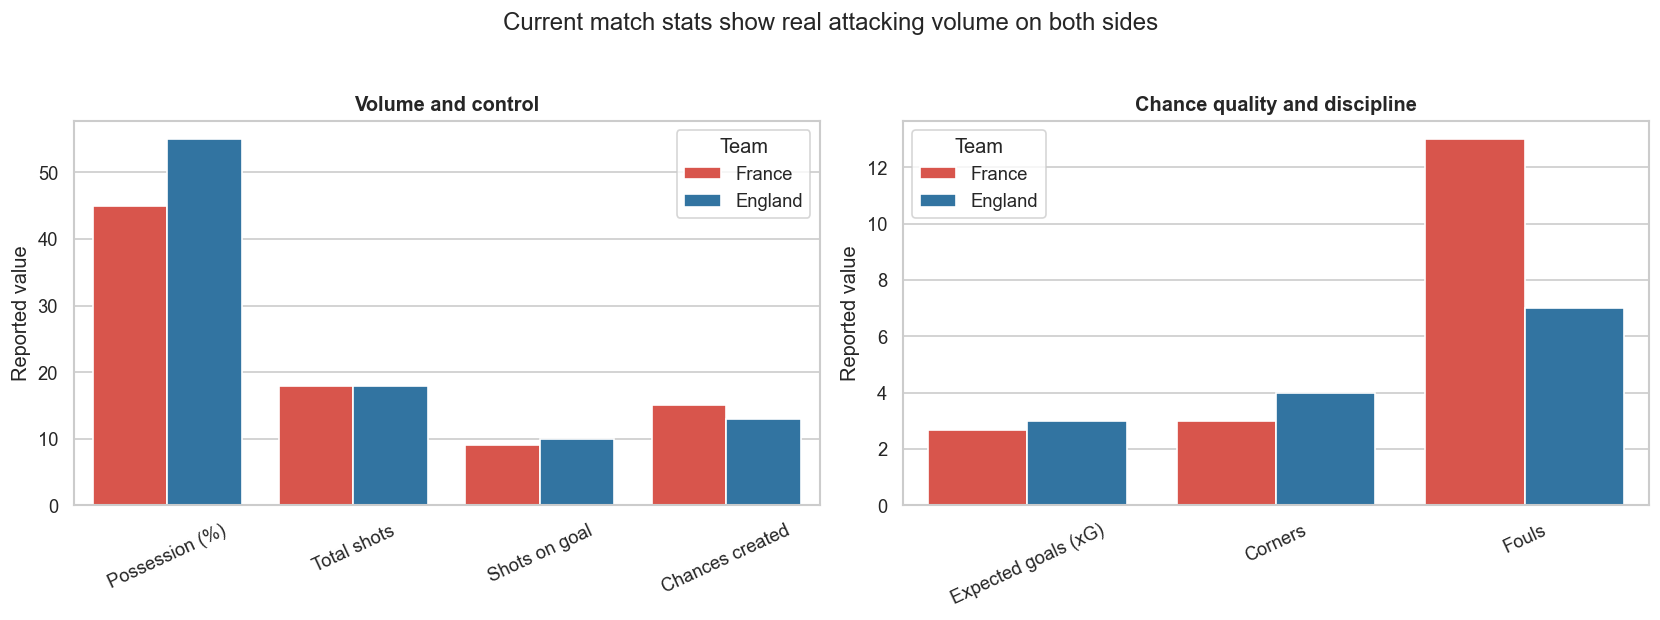

In [13]:
# Chart 4: current match box-score comparison
plot_metrics = ["Possession (%)", "Total shots", "Shots on goal", "Expected goals (xG)", "Chances created", "Corners", "Fouls"]
box = CURRENT_MATCH_STATS.loc[plot_metrics].reset_index().rename(columns={"metric": "Metric"})
box_long = box.melt(id_vars="Metric", var_name="Team", value_name="Value")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=box_long[box_long["Metric"].isin(["Possession (%)", "Total shots", "Shots on goal", "Chances created"])], x="Metric", y="Value", hue="Team", ax=axes[0], palette={"France": "#ef4135", "England": "#1f77b4"})
axes[0].set_title("Volume and control")
axes[0].set_xlabel("")
axes[0].set_ylabel("Reported value")
axes[0].tick_params(axis="x", rotation=25)

sns.barplot(data=box_long[box_long["Metric"].isin(["Expected goals (xG)", "Corners", "Fouls"])], x="Metric", y="Value", hue="Team", ax=axes[1], palette={"France": "#ef4135", "England": "#1f77b4"})
axes[1].set_title("Chance quality and discipline")
axes[1].set_xlabel("")
axes[1].set_ylabel("Reported value")
axes[1].tick_params(axis="x", rotation=25)
fig.suptitle("Current match stats show real attacking volume on both sides", y=1.03)
fig.tight_layout()
fig.savefig(ASSETS_DIR / "current_match_boxscore.png", bbox_inches="tight")
plt.show()

## Statistical tests

The primary outcome is total goals per match. Goal counts are discrete and skewed, so the main comparison uses Mann–Whitney U plus a match-label permutation test for the difference in means. A Fisher exact test checks whether a match reaches the simple “high-scoring” threshold of at least five total goals. The tests are descriptive: matches within a World Cup edition are not fully independent, and the third-place and Soccer Aid samples are only 20 and 15 matches.

In [14]:
# Non-parametric tests and effect sizes
third_scores = men.loc[men["context"] == "Third-place playoff", "total_goals"].to_numpy()
title_scores = men.loc[men["context"] == "Title-path knockout", "total_goals"].to_numpy()
group_scores = men.loc[men["context"] == "Group / second-group", "total_goals"].to_numpy()
fun_scores = soccer_aid["total_goals"].to_numpy()

def cliffs_delta(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    wins = sum(a > b for a in x for b in y)
    losses = sum(a < b for a in x for b in y)
    return (wins - losses) / (len(x) * len(y))

def permutation_mean_pvalue(x, y, n_resamples=20_000, seed=SEED):
    x = np.asarray(x)
    y = np.asarray(y)
    observed = x.mean() - y.mean()
    pooled = np.concatenate([x, y])
    local_rng = np.random.default_rng(seed)
    more_extreme = 0
    for _ in range(n_resamples):
        shuffled = local_rng.permutation(pooled)
        difference = shuffled[:len(x)].mean() - shuffled[len(x):].mean()
        more_extreme += abs(difference) >= abs(observed)
    return observed, (more_extreme + 1) / (n_resamples + 1)

def bootstrap_mean_difference_ci(x, y, n_resamples=20_000, seed=SEED):
    local_rng = np.random.default_rng(seed)
    differences = np.empty(n_resamples)
    for i in range(n_resamples):
        differences[i] = local_rng.choice(x, size=len(x), replace=True).mean() - local_rng.choice(y, size=len(y), replace=True).mean()
    return np.quantile(differences, [0.025, 0.975])

def compare_groups(label, x, y):
    observed, permutation_p = permutation_mean_pvalue(x, y)
    mw = stats.mannwhitneyu(x, y, alternative="two-sided")
    high = stats.fisher_exact([[int((x >= 5).sum()), int((x < 5).sum())], [int((y >= 5).sum()), int((y < 5).sum())]])
    ci = bootstrap_mean_difference_ci(x, y)
    return {
        "comparison": label,
        "n_x": len(x),
        "n_y": len(y),
        "mean_difference": observed,
        "bootstrap_95ci_low": ci[0],
        "bootstrap_95ci_high": ci[1],
        "mann_whitney_p": mw.pvalue,
        "permutation_mean_p": permutation_p,
        "fisher_high_goal_odds_ratio": high.statistic,
        "fisher_high_goal_p": high.pvalue,
        "cliffs_delta": cliffs_delta(x, y),
    }

test_results = pd.DataFrame([
    compare_groups("Third-place minus title-path knockout", third_scores, title_scores),
    compare_groups("Third-place minus group/second-group", third_scores, group_scores),
    compare_groups("Third-place minus Soccer Aid charity exhibition", third_scores, fun_scores),
])
display(test_results.round(3))

,comparison,n_x,n_y,mean_difference,bootstrap_95ci_low,bootstrap_95ci_high,mann_whitney_p,permutation_mean_p,fisher_high_goal_odds_ratio,fisher_high_goal_p,cliffs_delta
0,Third-place minus title-path knockout,20,226,0.654,-0.202,1.574,0.111,0.178,1.715,0.285,0.212
1,Third-place minus group/second-group,20,718,1.108,0.287,1.991,0.008,0.010,3.179,0.021,0.344
2,Third-place minus Soccer Aid charity exhibition,20,15,-1.333,-2.667,-0.033,0.063,0.069,0.471,0.321,-0.370


In [15]:
# Discipline context: bookings are available from 1970 onward in the reused database
men_bookings = bookings_raw[bookings_raw["tournament_name"].str.contains("Men's World Cup", regex=False, na=False)].copy()
cards_by_match = (
    men_bookings.groupby("match_id")
    .agg(
        yellow_cards=("yellow_card", "sum"),
        red_cards=("red_card", "sum"),
        sendings_off=("sending_off", "sum"),
    )
    .reset_index()
)
discipline = men.merge(cards_by_match, on="match_id", how="left").fillna({"yellow_cards": 0, "red_cards": 0, "sendings_off": 0})
discipline = discipline[discipline["edition_year"] >= 1970].copy()
discipline_summary = (
    discipline.groupby("context", observed=True)
    .agg(
        matches=("match_id", "size"),
        avg_yellow_cards=("yellow_cards", "mean"),
        avg_red_cards=("red_cards", "mean"),
        sending_off_rate=("sendings_off", lambda s: (s > 0).mean() * 100),
    )
)
display(discipline_summary.round(2))

display(Markdown("**Reading this table:** the card series is a secondary context, not a direct measure of competitiveness. Third-place sample size is especially small after 1970, and card recording/discipline norms changed over time."))

,matches,avg_yellow_cards,avg_red_cards,sending_off_rate
context,,,,
Group / second-group,588,3.12,0.12,15.82
Title-path knockout,162,4.14,0.15,22.22
Third-place playoff,14,2.93,0.00,0.00


**Reading this table:** the card series is a secondary context, not a direct measure of competitiveness. Third-place sample size is especially small after 1970, and card recording/discipline norms changed over time.

In [16]:
# Current-match competitiveness diagnostics
current_diagnostics = pd.Series({
    "total goals": len(current_goals),
    "England goals": int((current_goals["team"] == "England").sum()),
    "France goals": int((current_goals["team"] == "France").sum()),
    "half-time score": "England 4–0 France",
    "largest England lead": int(current_goals["england_score"].sub(current_goals["france_score"]).max()),
    "closest score after first goal": "England 4–3 France at 66'",
    "goals from 75' onward": int((current_goals["minute_decimal"] >= 75).sum()),
    "penalty goals": int((current_goals["goal_type"] == "penalty").sum()),
    "final margin": abs(CURRENT_MATCH["england_goals"] - CURRENT_MATCH["france_goals"]),
}, name="value")
display(current_diagnostics.to_frame())

display(Markdown("The score state matters: France never led, but it reduced a four-goal deficit to one goal by 66'. England then restored a two-goal cushion from a penalty at 87', France answered at 90+6', and Jude Bellingham closed the match at 90+8'. That is competitive as a contest, even though the final score was not a one-goal margin."))

,value
total goals,10
England goals,6
France goals,4
half-time score,England 4–0 France
largest England lead,4
closest score after first goal,England 4–3 France at 66'
goals from 75' onward,3
penalty goals,1
final margin,2


The score state matters: France never led, but it reduced a four-goal deficit to one goal by 66'. England then restored a two-goal cushion from a penalty at 87', France answered at 90+6', and Jude Bellingham closed the match at 90+8'. That is competitive as a contest, even though the final score was not a one-goal margin.

## Interpretation

- **Official, yes; title-level serious, no.** The third-place playoff is a FIFA World Cup match and counts in the tournament record, but it determines the bronze-medal position rather than the champion. Calling it a friendly would be incorrect; calling it lower-stakes than the semi-final/final is fair.
- **The match was unusually open.** It produced 10 goals, above the previous men's third-place maximum of 9 (France 6–3 West Germany in 1958) and the highest-scoring World Cup match since Hungary 10–1 El Salvador in 1982, according to AP.
- **Against the direct fun-match benchmark, third-place playoffs were less open on average.** Soccer Aid averaged 5.13 goals per match and reached 5+ goals in 53.3% of matches, compared with 3.80 and 35.0% for men's World Cup third-place playoffs. England–France's 10 goals exceeded every one of the 15 Soccer Aid matches in the benchmark, whose previous maximum was 9.
- **The statistical evidence is suggestive but not conclusive.** Third-place minus Soccer Aid was −1.33 goals per match; the Mann–Whitney p-value was 0.063 and the permutation p-value was 0.069. The small charity sample means this is close to, but not below, a conventional 5% threshold.
- **Historical context is nuanced.** Third-place playoffs averaged more goals than group/second-group matches in this sample, but their average was only directionally above title-path knockout matches. The pattern is consistent with loosened defending, but it cannot prove that players mentally treated the game as charity football.
- **The game itself was competitive in phases.** England's 4–0 half-time lead looked one-sided, but France's three goals in 18 second-half minutes brought the match back to 4–3. The two teams combined for 36 shots and 19 shots on goal, and their reported xG was 5.67.
- **Best overall verdict:** your intuition is partly supported. The 6–4 match behaved like a low-pressure scoring spectacle—indeed, it was even more open than the Soccer Aid sample—but the evidence is not strong enough to claim the teams treated it exactly like a charity match. It was a lower-stakes official match with charity-match-like risk-taking.

## Limitations and next steps

- The historical sample has only 20 men's third-place playoffs through 2022 and the Soccer Aid benchmark has 15 matches; p-values are sensitive to the threshold and era mix.
- Soccer Aid is not a like-for-like control: its squads mix celebrities, former professionals, and current/retired players, so roster quality and match incentives differ from two elite national teams.
- The Fjelstul data provides historical scores, goals, and bookings, but not a consistent historical possession/xG/shots panel. Current-match box-score statistics are therefore shown separately, not tested against historical xG.
- Third-place games are structurally forced to produce a placement, while group matches can finish drawn; final-margin comparisons should be interpreted with that format difference in mind.
- The current match and Soccer Aid snapshots are manually saved from cited sources so the notebook remains runnable offline; refresh the CSVs and source links if official reports are revised.
- A stronger follow-up would add event-level data for all World Cup matches and estimate scoring intensity, shot quality, and risk-taking while controlling for team strength, era, and score state.